# Week 3 · Task 2 — Prove the Central Limit Theorem to yourself

**Roadmap task:** *Take a deliberately ugly, lopsided distribution. Take averages of 1, then 5, then 30, then 100 samples. Plot each. Watch the bell curve appear from nowhere.*

**What this notebook shows**

1. An ugly population: skewed, with two humps and a long tail. Nothing like a bell.
2. The distribution of **sample averages** for $n = 1, 5, 30, 100$ — turning into a bell curve.
3. The two numbers the CLT predicts exactly: centre $\mu$ and spread $\sigma/\sqrt n$ (the **standard error**).
4. Measuring "how bell-shaped" with skewness, and a Q-Q plot.
5. **Where the CLT fails** — a distribution with no finite variance.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from mathkit.distributions import normal_pdf

FIG = pathlib.Path("figures"); FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(7)

## 1. The CLT in one sentence

**In simple words:** if you take the average of $n$ independent draws from *almost any* distribution, then for large enough $n$ that average behaves like a Normal random variable — no matter how ugly the original distribution was.

More precisely, if the population has mean $\mu$ and finite standard deviation $\sigma$:

$$\bar X_n = \frac{1}{n}\sum_{i=1}^n X_i \;\;\approx\;\; \text{Normal}\!\left(\mu,\; \frac{\sigma}{\sqrt n}\right) \quad\text{for large } n$$

Three separate claims hide in there:

| claim | true for any $n$? |
|---|---|
| the centre of $\bar X_n$ is $\mu$ | ✅ always (just linearity of expectation) |
| the spread of $\bar X_n$ is $\sigma/\sqrt n$ | ✅ always (variances of independent things add) |
| the **shape** is Normal | ❌ only approximately, and only as $n$ grows — *this* is the CLT |

## 2. Build an ugly population

A mixture: 60% exponential waiting times (skewed), 30% a tight hump around 8, 10% a far-away hump around 20.

In [2]:
def ugly(size):
    """Draw from a deliberately ugly, lopsided, bumpy distribution."""
    which = rng.choice(3, size=size, p=[0.6, 0.3, 0.1])
    out = np.empty(size)
    out[which == 0] = rng.exponential(1.5, (which == 0).sum())
    out[which == 1] = rng.normal(8, 0.6, (which == 1).sum())
    out[which == 2] = rng.uniform(18, 22, (which == 2).sum())
    return out

population = ugly(2_000_000)          # a huge sample stands in for the true population
mu, sigma = population.mean(), population.std()
print(f"population mean μ ≈ {mu:.3f},  standard deviation σ ≈ {sigma:.3f}")

population mean μ ≈ 5.296,  standard deviation σ ≈ 5.830


## 3. Averages of 1, 5, 30 and 100 draws

For each $n$: repeat the experiment 50,000 times — draw $n$ values, average them — and histogram the 50,000 averages. The black curve is the Normal the CLT predicts: $\text{Normal}(\mu, \sigma/\sqrt n)$. **Nothing is fitted to the data.**

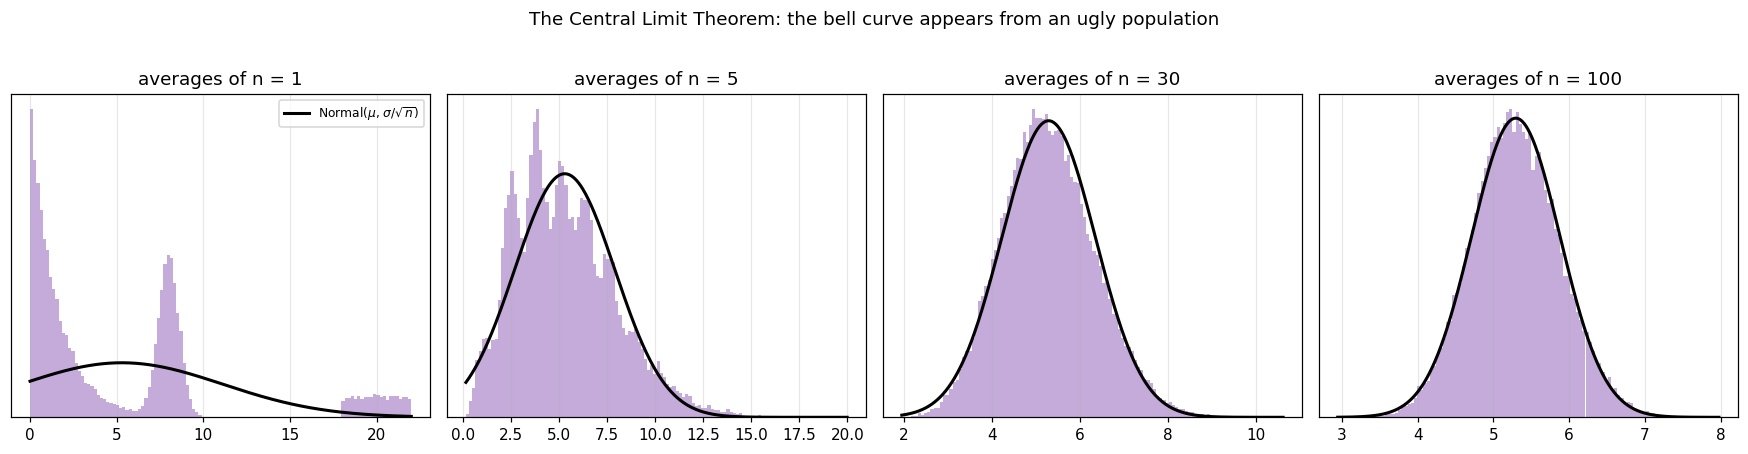

   n | mean of averages | sd of averages | σ/√n predicted | skewness
   1 |            5.317 |          5.854 |          5.830 |    1.434
   5 |            5.308 |          2.602 |          2.607 |    0.643
  30 |            5.300 |          1.064 |          1.064 |    0.272
 100 |            5.299 |          0.585 |          0.583 |    0.153


In [3]:
n_experiments = 50_000
ns = [1, 5, 30, 100]

def skewness(x):
    z = (x - x.mean()) / x.std()
    return float(np.mean(z ** 3))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
summary = []
for ax, n in zip(axes, ns):
    means = ugly(n_experiments * n).reshape(n_experiments, n).mean(axis=1)
    se = sigma / np.sqrt(n)
    x = np.linspace(means.min(), means.max(), 400)
    ax.hist(means, bins=120, density=True, alpha=0.55, color="tab:purple")
    ax.plot(x, normal_pdf(x, mu, se), "k", lw=2, label=r"Normal($\mu$, $\sigma/\sqrt{n}$)")
    ax.set_title(f"averages of n = {n}")
    ax.set_yticks([])
    summary.append((n, means.mean(), means.std(), se, skewness(means)))
axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("The Central Limit Theorem: the bell curve appears from an ugly population", y=1.02)
fig.tight_layout(); fig.savefig(FIG / "w3_clt.png", dpi=150, bbox_inches="tight"); plt.show()

print(f"{'n':>4} | {'mean of averages':>16} | {'sd of averages':>14} | {'σ/√n predicted':>14} | {'skewness':>8}")
for n, m, s, se, sk in summary:
    print(f"{n:>4} | {m:>16.3f} | {s:>14.3f} | {se:>14.3f} | {sk:>8.3f}")

**Read the table.**

* **Mean of averages** equals $\mu$ at every $n$ — even $n=1$.
* **Spread** matches $\sigma/\sqrt n$ at every $n$. Four times as much data → half the wobble. That $\sqrt n$ is why collecting 100× more data only makes you 10× more precise.
* **Skewness** (0 for a perfect bell) shrinks towards 0. For a sum of independent draws it shrinks like $1/\sqrt n$, which you can check: the population's skewness divided by $\sqrt{n}$.

## 4. A sharper test: the Q-Q plot

A histogram can fool the eye. A **Q-Q plot** sorts the averages and plots them against where a perfect Normal would put them. A perfect Normal gives a straight diagonal line; bends at the ends mean the tails are wrong.

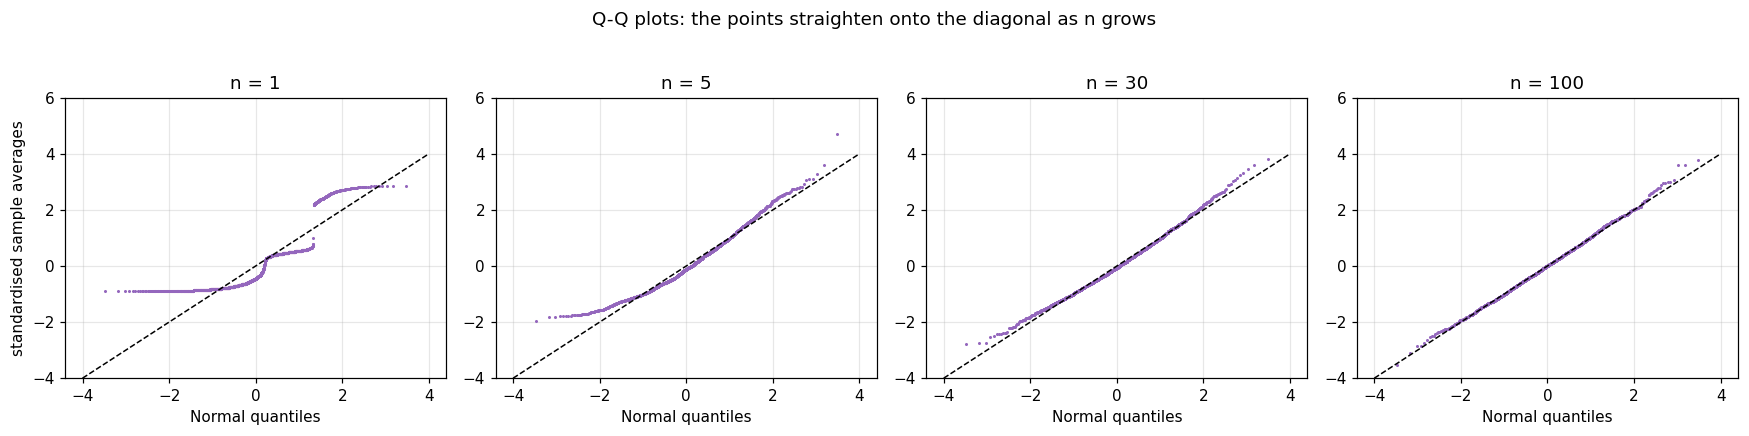

In [4]:
def normal_quantiles(m):
    """Expected standard-normal quantiles for m sorted points (via inverting the CDF by bisection)."""
    from math import erf, sqrt
    probs = (np.arange(1, m + 1) - 0.5) / m
    lo, hi = np.full(m, -10.0), np.full(m, 10.0)
    for _ in range(60):
        mid = (lo + hi) / 2
        cdf = 0.5 * (1 + np.vectorize(erf)(mid / sqrt(2)))
        lo = np.where(cdf < probs, mid, lo); hi = np.where(cdf < probs, hi, mid)
    return (lo + hi) / 2

m = 2000
q_theory = normal_quantiles(m)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharex=True)
for ax, n in zip(axes, ns):
    means = ugly(m * n).reshape(m, n).mean(axis=1)
    z = np.sort((means - mu) / (sigma / np.sqrt(n)))       # standardise
    ax.plot(q_theory, z, ".", ms=2, color="tab:purple")
    ax.plot([-4, 4], [-4, 4], "k--", lw=1)
    ax.set_title(f"n = {n}"); ax.set_xlabel("Normal quantiles"); ax.set_ylim(-4, 6)
axes[0].set_ylabel("standardised sample averages")
fig.suptitle("Q-Q plots: the points straighten onto the diagonal as n grows", y=1.03)
fig.tight_layout(); fig.savefig(FIG / "w3_clt_qq.png", dpi=150, bbox_inches="tight"); plt.show()

At $n = 30$ the middle is straight but the **right tail still bends up** — the skew hasn't fully gone. "$n \ge 30$ is enough" is a rule of thumb, not a law; for very skewed data you need more. Remember this in Week 4: a confidence interval that assumes normality can be off when $n$ is small and data is skewed.

## 5. Where the CLT breaks — the Cauchy distribution

The CLT needs a **finite variance**. The Cauchy distribution (the ratio of two independent standard normals) has tails so heavy that its mean and variance do not exist. Averaging does **not** help at all — the average of 1,000 Cauchy draws is exactly as wild as a single draw.

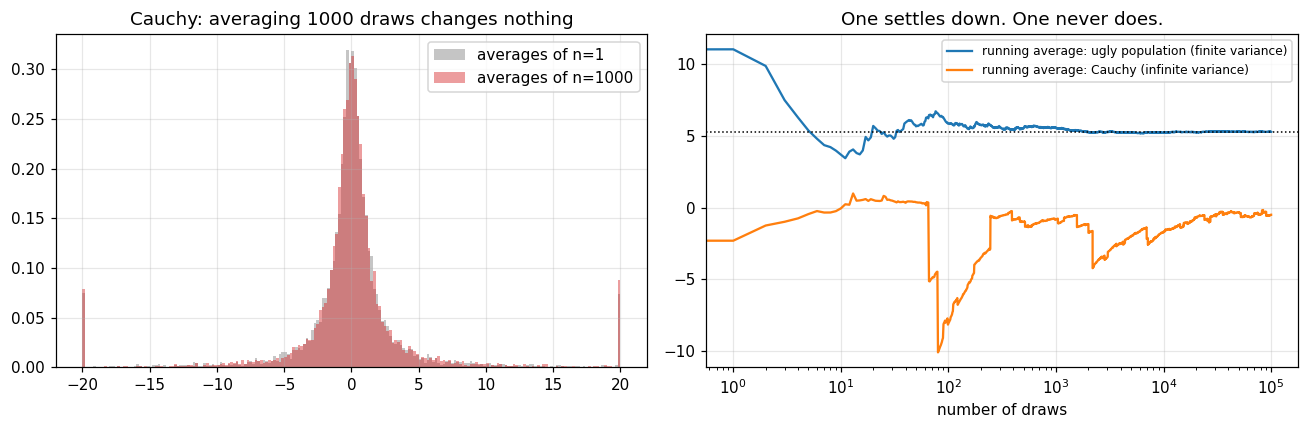

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for n, color in [(1, "tab:gray"), (1000, "tab:red")]:
    avgs = rng.standard_cauchy((10_000, n)).mean(axis=1)
    axes[0].hist(np.clip(avgs, -20, 20), bins=200, density=True, alpha=0.45, color=color, label=f"averages of n={n}")
axes[0].set_title("Cauchy: averaging 1000 draws changes nothing"); axes[0].legend()

stream_cauchy = np.cumsum(rng.standard_cauchy(100_000)) / np.arange(1, 100_001)
stream_ugly = np.cumsum(ugly(100_000)) / np.arange(1, 100_001)
axes[1].semilogx(stream_ugly, label="running average: ugly population (finite variance)")
axes[1].semilogx(stream_cauchy, label="running average: Cauchy (infinite variance)")
axes[1].axhline(mu, color="k", ls=":", lw=1)
axes[1].set_xlabel("number of draws"); axes[1].set_title("One settles down. One never does."); axes[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "w3_clt_cauchy.png", dpi=150); plt.show()

**Why this matters in real work:** heavy-tailed data (revenue per user, file sizes, city populations) is not Cauchy, but it can be close enough that averages converge *very* slowly. One whale customer can move your A/B test's mean. That's why medians, trimming, or log-transforms appear in practice.

## 6. What to write in your lab notebook

* The average of $n$ independent draws has centre $\mu$ and spread $\sigma/\sqrt n$ — **always**.
* Its *shape* becomes Normal as $n$ grows — **the CLT**. How fast depends on how skewed the data is.
* It needs finite variance. Heavy tails → slow or no convergence.
* This is why so much of statistics works: we almost always report averages (means, proportions, regression coefficients), and averages are approximately Normal, so we can put a ± on them.

## 7. Your turn

1. Replace `ugly` with a Bernoulli(0.05) (a rare event, like a 5% conversion rate). How big must $n$ be before the averages look Normal? (This is exactly the A/B-testing situation of Week 17.)
2. Instead of the average, try the **maximum** of $n$ draws. Does a bell appear? Why not? (The CLT is about sums/averages specifically.)
3. **Explain out loud:** "Why do averages of almost anything look like a bell curve, and what does σ/√n tell you?"